In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

RAW = Path("../data/raw")
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

print("Libraries ready ✓")

Libraries ready ✓


In [2]:
# Cell 2 — Load data
train = pd.read_csv(RAW / "drugsComTrain_raw.csv")
test  = pd.read_csv(RAW / "drugsComTest_raw.csv")

print(f"Train: {train.shape}")
print(f"Test : {test.shape}")
print(f"\nColumns: {train.columns.tolist()}")
print(f"\nRating distribution:")
print(train['rating'].value_counts().sort_index())
print(f"\nMissing values:")
print(train.isnull().sum())

Train: (161297, 7)
Test : (53766, 7)

Columns: ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']

Rating distribution:
rating
1     21619
2      6931
3      6513
4      5012
5      8013
6      6343
7      9456
8     18890
9     27531
10    50989
Name: count, dtype: int64

Missing values:
uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64


In [3]:
# Cell 3 — Sentiment labels banao (rating se)
def rating_to_sentiment(rating):
    if rating >= 7:
        return "positive"
    elif rating >= 4:
        return "neutral"
    else:
        return "negative"

train['sentiment'] = train['rating'].apply(rating_to_sentiment)
test['sentiment']  = test['rating'].apply(rating_to_sentiment)

print("Sentiment Distribution (Train):")
print(train['sentiment'].value_counts())
print(f"\nPercentage:")
print(train['sentiment'].value_counts(normalize=True).mul(100).round(1))

Sentiment Distribution (Train):
sentiment
positive    106866
negative     35063
neutral      19368
Name: count, dtype: int64

Percentage:
sentiment
positive    66.3
negative    21.7
neutral     12.0
Name: proportion, dtype: float64


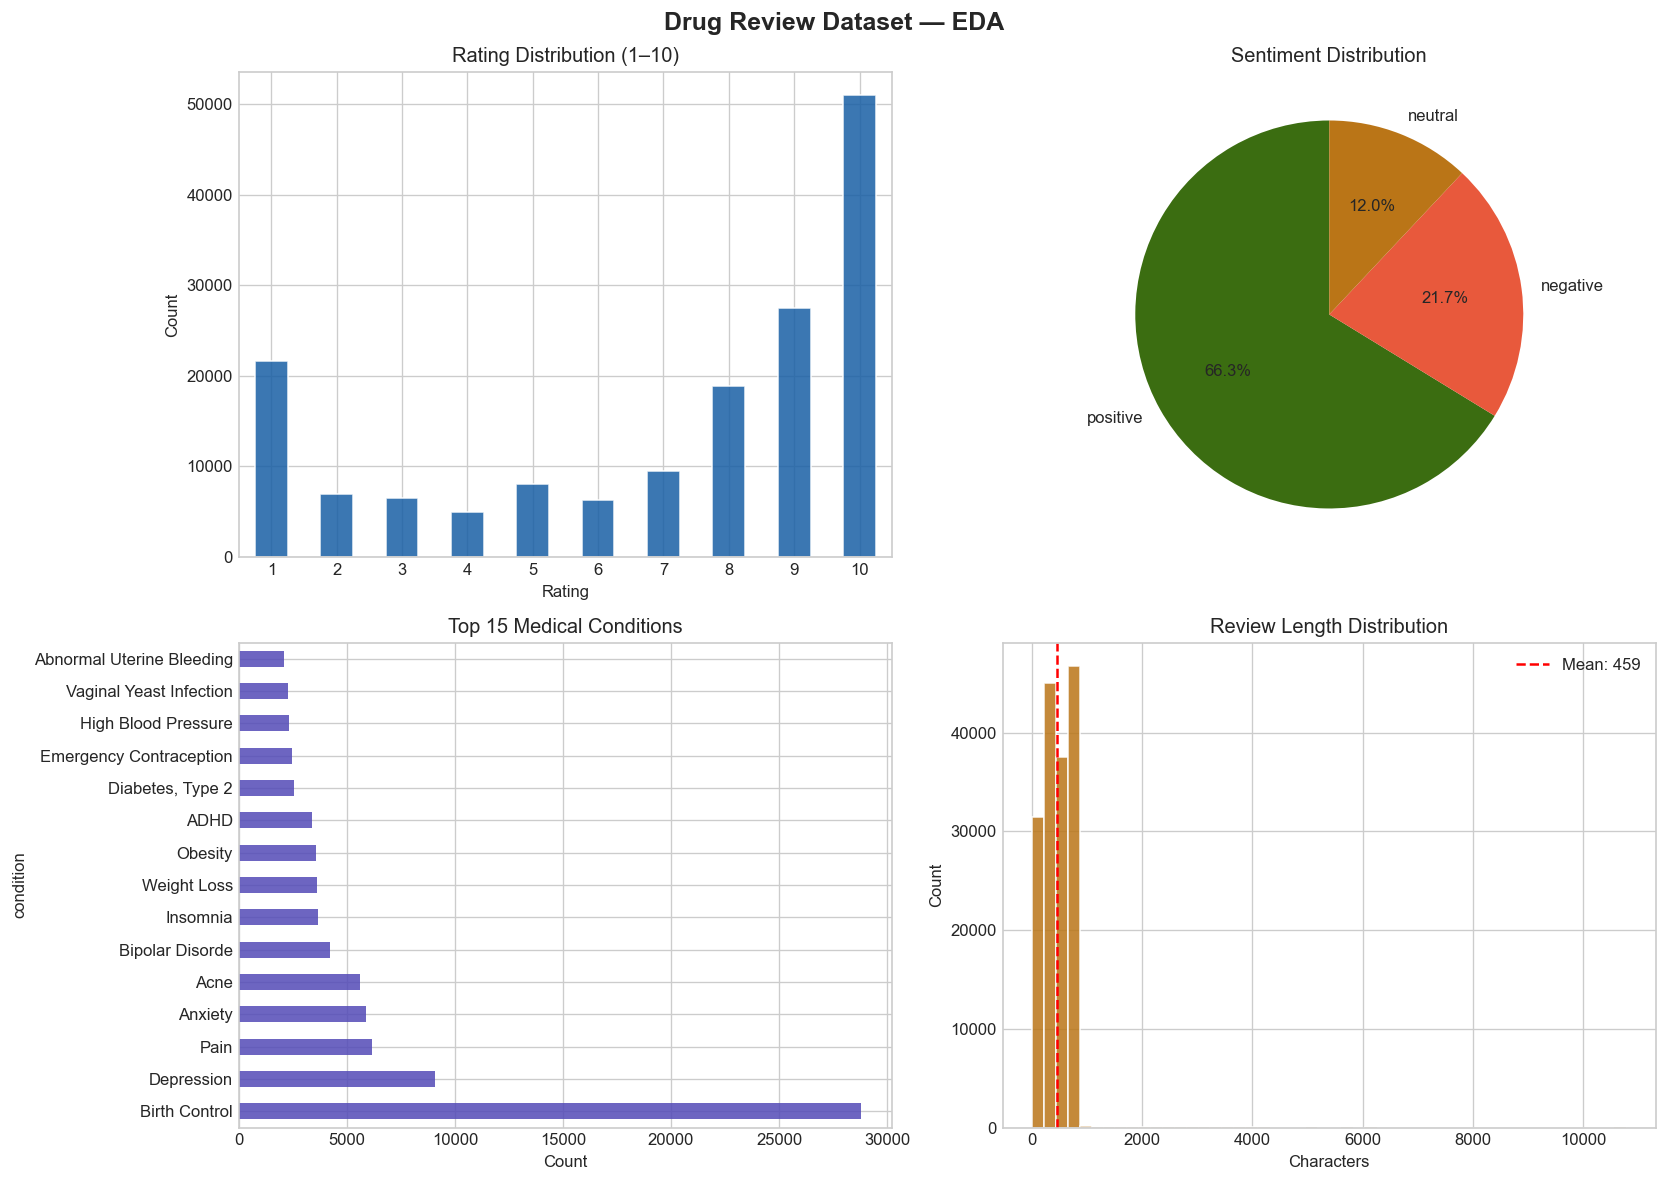

Saved ✓


In [4]:
# Cell 4 — EDA Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Drug Review Dataset — EDA", fontsize=15, fontweight='bold')

# Plot 1: Rating distribution
ax = axes[0,0]
train['rating'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#185FA5', alpha=0.85, edgecolor='white')
ax.set_title("Rating Distribution (1–10)")
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)

# Plot 2: Sentiment distribution
ax = axes[0,1]
colors = {"positive":"#3B6D11","neutral":"#BA7517","negative":"#E8593C"}
sentiment_counts = train['sentiment'].value_counts()
ax.pie(sentiment_counts.values,
       labels=sentiment_counts.index,
       colors=[colors[s] for s in sentiment_counts.index],
       autopct='%1.1f%%', startangle=90)
ax.set_title("Sentiment Distribution")

# Plot 3: Top 15 conditions
ax = axes[1,0]
top_conditions = train['condition'].value_counts().head(15)
top_conditions.plot(kind='barh', ax=ax, color='#534AB7', alpha=0.85)
ax.set_title("Top 15 Medical Conditions")
ax.set_xlabel("Count")

# Plot 4: Review length distribution
ax = axes[1,1]
train['review_length'] = train['review'].str.len()
ax.hist(train['review_length'], bins=50,
        color='#BA7517', alpha=0.85, edgecolor='white')
ax.set_title("Review Length Distribution")
ax.set_xlabel("Characters"); ax.set_ylabel("Count")
ax.axvline(train['review_length'].mean(), color='red',
           linestyle='--', label=f"Mean: {train['review_length'].mean():.0f}")
ax.legend()

plt.tight_layout()
plt.savefig(FIG / "01_eda_overview.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ✓")

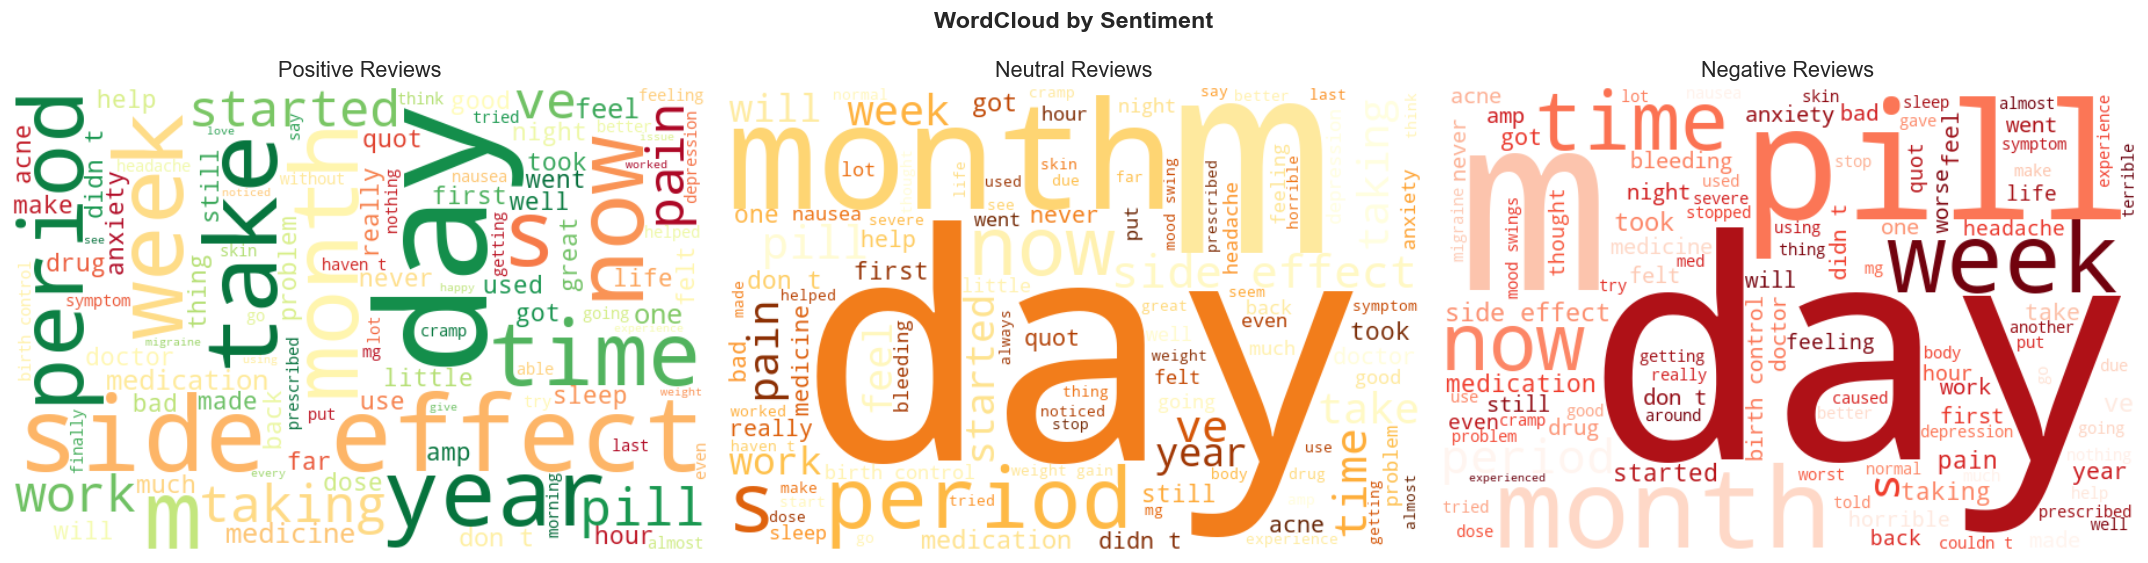

Saved ✓


In [5]:
# Cell 5 — WordClouds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("WordCloud by Sentiment", fontsize=14, fontweight='bold')

wc_colors = {
    "positive": "#3B6D11",
    "neutral" : "#BA7517",
    "negative": "#E8593C"
}

for ax, sentiment in zip(axes, ["positive","neutral","negative"]):
    text = " ".join(
        train[train['sentiment']==sentiment]['review']
        .str.replace('"','').dropna().sample(2000, random_state=42)
    )
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='RdYlGn' if sentiment=='positive' else
                 'YlOrBr' if sentiment=='neutral' else 'Reds',
        max_words=100
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{sentiment.capitalize()} Reviews", fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIG / "02_wordclouds.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ✓")

In [6]:
# Cell 6 — Save processed data
import html

def clean_review(text):
    text = str(text)
    text = html.unescape(text)        # &amp; → &
    text = text.replace('"', '')      # quotes hata do
    text = text.strip()
    return text

train['review_clean'] = train['review'].apply(clean_review)
test['review_clean']  = test['review'].apply(clean_review)

# Save processed
PROC = Path("../data/processed")
PROC.mkdir(exist_ok=True)

train.to_csv(PROC / "train_processed.csv", index=False)
test.to_csv(PROC  / "test_processed.csv",  index=False)

print("Processed data saved ✓")
print(f"\nTrain: {train.shape}")
print(f"Test : {test.shape}")
print(f"\nSample clean review:")
print(train['review_clean'].iloc[0][:200])

Processed data saved ✓

Train: (161297, 10)
Test : (53766, 9)

Sample clean review:
It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil


In [7]:
# Cell 7 — Key Stats
print("="*55)
print("KEY STATISTICS")
print("="*55)
print(f"Total reviews       : {len(train)+len(test):,}")
print(f"Train reviews       : {len(train):,}")
print(f"Test reviews        : {len(test):,}")
print(f"Unique drugs        : {train['drugName'].nunique():,}")
print(f"Unique conditions   : {train['condition'].nunique():,}")
print(f"Avg review length   : {train['review_length'].mean():.0f} chars")
print(f"Positive reviews    : {(train['sentiment']=='positive').mean()*100:.1f}%")
print(f"Neutral reviews     : {(train['sentiment']=='neutral').mean()*100:.1f}%")
print(f"Negative reviews    : {(train['sentiment']=='negative').mean()*100:.1f}%")
print("="*55)
print("\nNext → 02_baseline.ipynb")

KEY STATISTICS
Total reviews       : 215,063
Train reviews       : 161,297
Test reviews        : 53,766
Unique drugs        : 3,436
Unique conditions   : 884
Avg review length   : 459 chars
Positive reviews    : 66.3%
Neutral reviews     : 12.0%
Negative reviews    : 21.7%

Next → 02_baseline.ipynb
